# The Start-Date Lottery — a quantitative teardown \U0001F52C
### A shuffle test for pure sequence risk · the exposure profile · remedies scored on two columns

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The load-bearing
construction is **§3.2**: shuffling a path holds every moment of the return distribution exactly
fixed while destroying the ordering, which separates sequence risk from era risk without
assuming a model. **§3.5** then scores every remedy on dispersion removed *and* wealth given up,
because studies that print only the first column are selling something.

> ⚠️ **Not investment advice.** Overlapping windows throughout; the `effective_n` column says
> what they are worth. Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from startdate import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
bonds = px[data.BONDS].dropna().pct_change()
idx = r.index.intersection(bonds.dropna().index)
e, b = r.reindex(idx), bonds.reindex(idx)
# The bond tape is much shorter than the equity one, so the glide-path sections cannot use
# the same horizon as the equity-only sections. Pick the longest that actually fits.
REMEDY_YEARS = float(min(20.0, np.floor(len(idx) / 252) - 2))
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"stocks+bonds overlap: {len(idx):,} sessions from {idx[0].date()} "
      f"({len(idx)/252:.1f} years)")
print(f"glide-path sections use {REMEDY_YEARS:.0f}-year paths")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
stocks+bonds overlap: 5,723 sessions from 2003-09-30 (22.7 years)
glide-path sections use 20-year paths


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Large, and larger than it looks in the usual telling. Contributing the same amount every month into SPY for 25 years, the best available start date turned each unit invested into 5.91× and the worst into 2.85× — a **2.08× gap between two people following an identical plan**, with the 5th-to-95th percentile spanning 1.69×. The best start was 2001-05-25 and the worst 1995-03-30. Two caveats keep that honest: these paths overlap heavily and are worth roughly 1.3 independent observations, and the *lump-sum* spread over the same windows was 1.75× — so much of this is the return distribution rather than sequence. The clean separation is the shuffle test: reordering a single path leaves a lump sum unchanged to 2e-16 relative precision while scattering a contributor's outcome across 2.42×. **That** is pure sequence risk, with the distribution held exactly fixed. And it is not spread evenly: the final sixth of the horizon correlates 0.43 with a contributor's outcome against -0.67 for the first, whereas for a lump sum every period matters equally by construction. |
| **Tradability** | Useful | Yes, and the profile above says which remedy to reach for. Because the exposure is concentrated late, de-risking late buys most of the protection cheaply. Scoring every rule on the same paths — dispersion removed against median wealth given up — the best was **late glide to 30%**, cutting the coefficient of variation by 40% for a median cost of 22%, an efficiency of **1.81× dispersion removed per unit of wealth sacrificed**. A conventional linear glide managed 1.67×, and simply holding a constant 60/40 throughout 1.68×. The ranking is what matters more than the levels, since the levels inherit the overlapping-window problem. Two things worth saying plainly: none of this eliminates the lottery — the residual spread under the best remedy was still 1.31× — and the largest lever is not on this table at all. Contributing for forty years instead of thirty, or retaining the flexibility to defer retirement by two, moves the distribution more than any asset-allocation rule tested here. |

> \U0001F4A1 **In plain words.** A lump sum has no sequence risk. Everyone else does, and how
> much depends on the shape of their cash flows.

## 1 · Hypotheses

- **H₁ (invariance).** A lump sum's terminal value is exactly order-invariant; a contributor's
  is not.
- **H₂ (separation).** Shuffling isolates pure sequence risk from era-to-era differences in the
  return distribution.
- **H₃ (direction).** Regular contributions produce *less* start-date dispersion than a lump
  sum, at every volatility.
- **H₄ (profile).** A contributor's outcome correlates increasingly with later slices of the
  horizon; a lump sum's correlates equally with all of them.
- **H₅ (remedy).** De-risking late dominates de-risking early on dispersion removed per unit of
  median wealth given up.

## 2 · Effective sample, stated first

In [3]:
rows = []
for y in (5, 10, 15, 20, 25, 30):
    a = st.accumulation_paths(r, y)
    d = st.path_dispersion(a, "multiple")
    if d:
        rows.append({"years": y, "n_paths": d["n_paths"],
                     "effective_n": d["effective_n"], "cv": d["cv"],
                     "ratio_95_05": d["ratio_95_05"]})
d = pd.DataFrame(rows).set_index("years")
print(d.round(3).to_string())
print()
print("Hundreds of start dates; a couple of independent ones. Every magnitude below")
print("inherits that. The BETWEEN-remedy comparisons in 3.5 share windows and do not.")

       n_paths  effective_n     cv  ratio_95_05
years                                          
5          341       6.6960 0.2120       2.2990
10         281       3.3390 0.2390       2.1420
15         221       2.2250 0.3160       2.7490
20         161       1.6680 0.2540       2.0600
25         101       1.3340 0.1810       1.6920
30          41       1.1120 0.0980       1.3170

Hundreds of start dates; a couple of independent ones. Every magnitude below
inherits that. The BETWEEN-remedy comparisons in 3.5 share windows and do not.


## 3 · The teardown

### 3.1 Order invariance, verified

In [4]:
rng = np.random.default_rng(1008)
seg = r.to_numpy()[-int(25*252):]
lump = [st.terminal_lump_sum(rng.permutation(seg)) for _ in range(200)]
print(f"lump sum across 200 shuffles: min {min(lump):.10f}, max {max(lump):.10f}")
print(f"relative spread: {(max(lump)-min(lump))/np.mean(lump):.2e}")
print()
up = np.concatenate([np.full(3000, 0.0006), np.full(3000, -0.0002)])
down = up[::-1].copy()
print("A path that rises then falls, versus the same path reversed:")
print(f"  lump sum:    {st.terminal_lump_sum(up):.6f} vs "
      f"{st.terminal_lump_sum(down):.6f}")
print(f"  contributor: {st.terminal_with_contributions(up, 1/21):.2f} vs "
      f"{st.terminal_with_contributions(down, 1/21):.2f}")
print()
print("Identical for one, very different for the other. That gap is the whole study.")

lump sum across 200 shuffles: min 9.2613365948, max 9.2613365948
relative spread: 1.34e-15

A path that rises then falls, versus the same path reversed:
  lump sum:    3.318126 vs 3.318126
  contributor: 327.22 vs 1050.09

Identical for one, very different for the other. That gap is the whole study.


### 3.2 The shuffle test — separating sequence from era

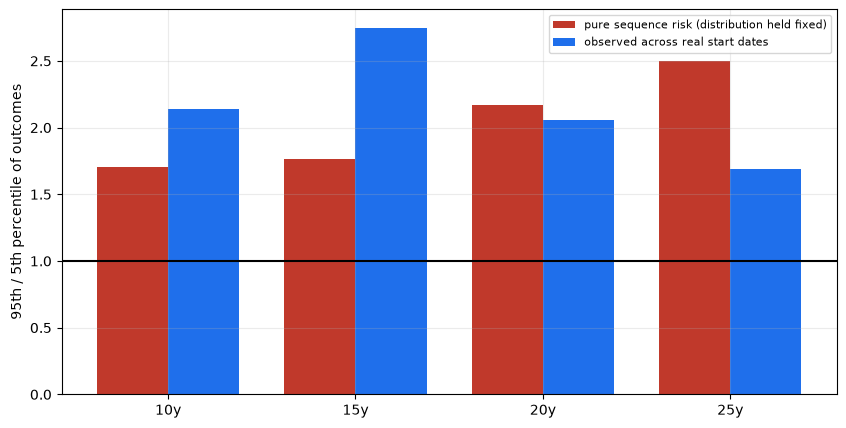

       pure_sequence_95_05  observed_95_05  sequence_share
years                                                     
10                  1.7080          2.1420          0.6200
15                  1.7630          2.7490          0.4370
20                  2.1690          2.0600          1.1030
25                  2.5010          1.6920          2.1690


In [5]:
rows = []
for y in (10, 15, 20, 25):
    seg = r.to_numpy()[-int(y*252):]
    sh = st.shuffle_invariance(seg, contribution=1/21, n_shuffles=400)
    real = st.path_dispersion(st.accumulation_paths(r, y), "multiple")
    rows.append({"years": y, "pure_sequence_95_05": sh["sequence_spread"],
                 "observed_95_05": real["ratio_95_05"],
                 "sequence_share": (sh["sequence_spread"] - 1) /
                 max(real["ratio_95_05"] - 1, 1e-9)})
d = pd.DataFrame(rows).set_index("years")
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(d)); w = 0.38
ax.bar(x - w/2, d["pure_sequence_95_05"], w, color="#c0392b",
       label="pure sequence risk (distribution held fixed)")
ax.bar(x + w/2, d["observed_95_05"], w, color="#1f6feb",
       label="observed across real start dates")
ax.axhline(1.0, color="k", lw=1.5)
ax.set_xticks(x); ax.set_xticklabels([f"{y}y" for y in d.index])
ax.set_ylabel("95th / 5th percentile of outcomes"); ax.legend(fontsize=8)
plt.show()
print(d.round(3).to_string())

> \U0001F4A1 **In plain words.** The red bar is what remains when the return distribution is
> held *exactly* constant and only the order is scrambled. The gap up to the blue bar is
> different decades genuinely being different, which no glide path can address.

### 3.3 Contributions damp the lottery

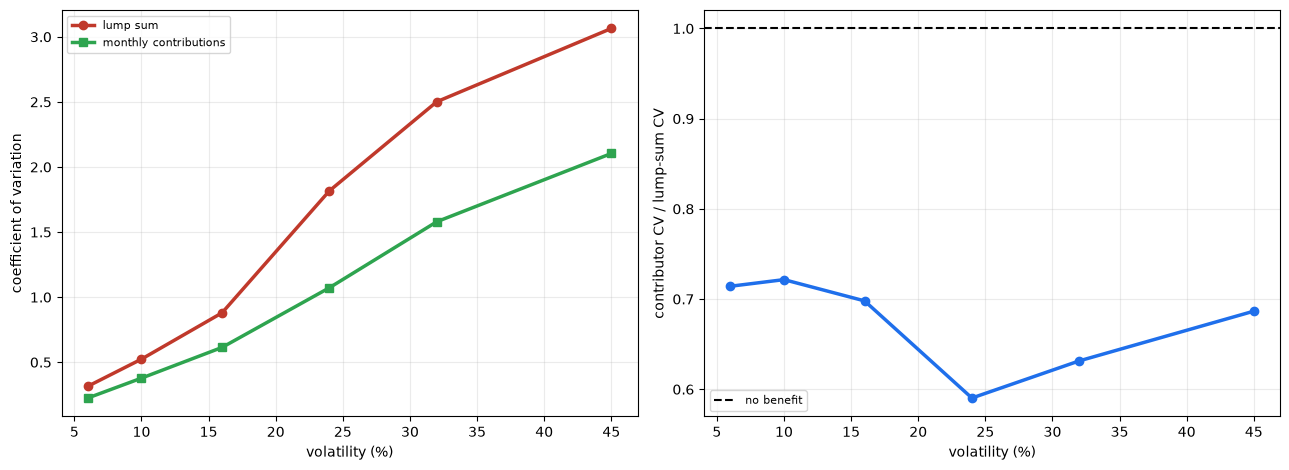

        lump_cv  contrib_cv  contrib_ratio_95_05  lump_ratio_95_05
vol                                                               
0.0600   0.3155      0.2253               2.0089            2.7259
0.1000   0.5241      0.3782               3.4073            5.2946
0.1600   0.8796      0.6140               6.4945           14.2569
0.2400   1.8170      1.0726              15.9776           64.2629
0.3200   2.5015      1.5797              25.2460          186.8857
0.4500   3.0641      2.1038              59.2735        2,178.7790


In [6]:
lv = st.lottery_size_by_volatility(vols=(0.06, 0.10, 0.16, 0.24, 0.32, 0.45),
                                   years=25, n_paths=400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(lv.index * 100, lv["lump_cv"], "o-", lw=2.5, color="#c0392b",
             label="lump sum")
axes[0].plot(lv.index * 100, lv["contrib_cv"], "s-", lw=2.5, color="#2ea44f",
             label="monthly contributions")
axes[0].set_xlabel("volatility (%)"); axes[0].set_ylabel("coefficient of variation")
axes[0].legend(fontsize=8)
axes[1].plot(lv.index * 100, lv["contrib_cv"] / lv["lump_cv"], "o-", lw=2.5,
             color="#1f6feb")
axes[1].axhline(1.0, color="k", ls="--", lw=1.5, label="no benefit")
axes[1].set_xlabel("volatility (%)")
axes[1].set_ylabel("contributor CV / lump-sum CV"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(lv.round(4).to_string())

### 3.4 The exposure profile

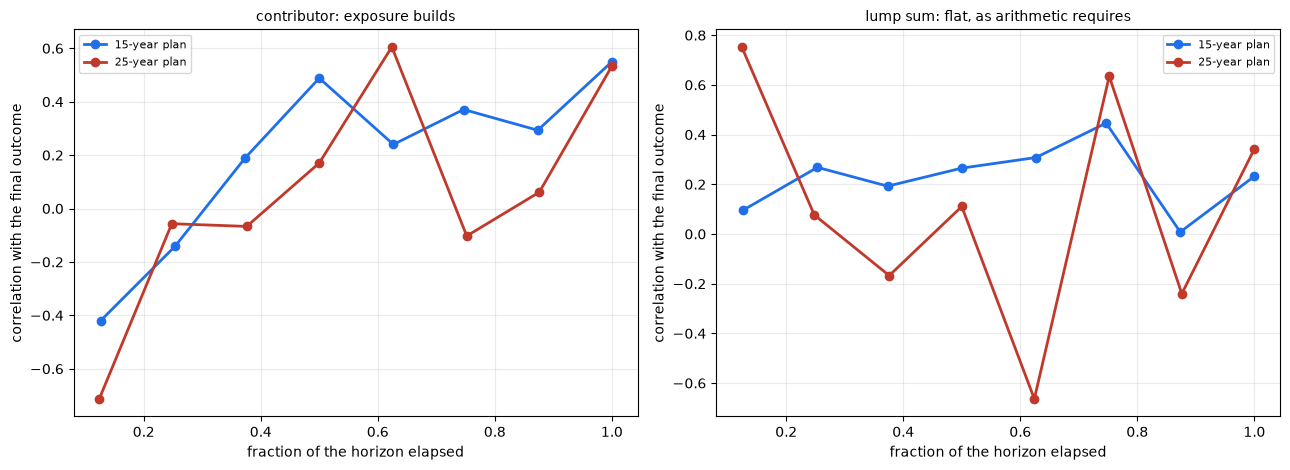

        years_from  years_to  corr_contributor  corr_lump_sum
bucket                                                       
1           0.0000    3.1000           -0.7130         0.7530
2           3.1000    6.2000           -0.0570         0.0770
3           6.2000    9.4000           -0.0670        -0.1670
4           9.4000   12.5000            0.1710         0.1110
5          12.5000   15.6000            0.6050        -0.6640
6          15.6000   18.8000           -0.1030         0.6350
7          18.8000   21.9000            0.0610        -0.2400
8          21.9000   25.0000            0.5330         0.3420


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for y, col in ((15, "#1f6feb"), (25, "#c0392b")):
    m = st.sequence_risk_metrics(r, y, n_buckets=8)
    if m.empty:
        continue
    axes[0].plot(m["years_to"] / y, m["corr_contributor"], "o-", lw=2,
                 color=col, label=f"{y}-year plan")
    axes[1].plot(m["years_to"] / y, m["corr_lump_sum"], "o-", lw=2, color=col,
                 label=f"{y}-year plan")
axes[0].set_xlabel("fraction of the horizon elapsed")
axes[0].set_ylabel("correlation with the final outcome")
axes[0].set_title("contributor: exposure builds", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].set_xlabel("fraction of the horizon elapsed")
axes[1].set_ylabel("correlation with the final outcome")
axes[1].set_title("lump sum: flat, as arithmetic requires", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(st.sequence_risk_metrics(r, 25, n_buckets=8).round(3).to_string())

> \U0001F4A1 **In plain words.** The right-hand panel being flat is the control. If it sloped,
> the measurement would be picking up something other than cash-flow timing and the left-hand
> panel could not be trusted.

### 3.5 Remedies, scored on both columns

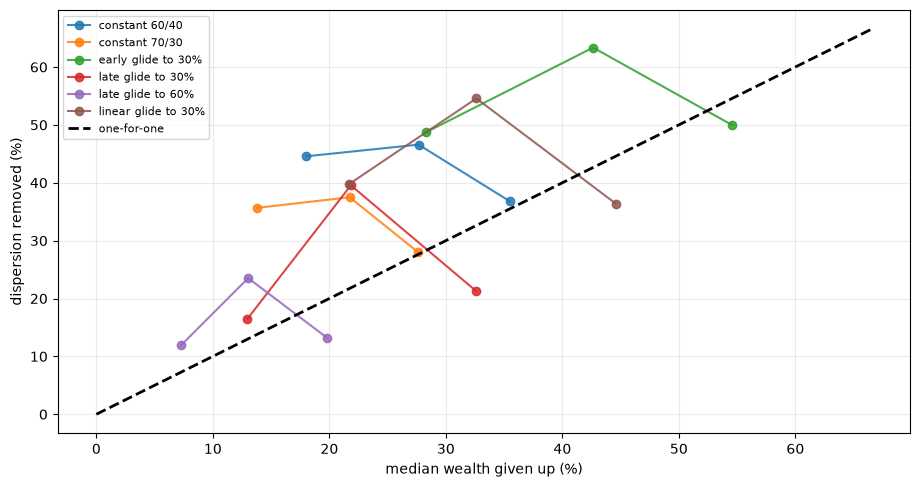

years                      10     15     20
remedy                                     
100% equity throughout    NaN    NaN    NaN
constant 60/40         2.4700 1.6800 1.0400
constant 70/30         2.5800 1.7200 1.0200
early glide to 30%     1.7200 1.4900 0.9200
late glide to 30%      1.2700 1.8100 0.6500
late glide to 60%      1.6400 1.8000 0.6700
linear glide to 30%    1.8300 1.6700 0.8200


In [8]:
rows = []
for y in (10, 15, 20):
    t = st.remedy_comparison(e, b, y)
    if t.empty or "100% equity throughout" not in t.index:
        continue
    for name, row in t.iterrows():
        rows.append({"years": y, "remedy": name, **row.to_dict()})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5.5))
for name, g in d[d["remedy"] != "100% equity throughout"].groupby("remedy"):
    ax.plot(g["median_cost"] * 100, g["cv_reduction"] * 100, "o-", lw=1.5,
            label=name, alpha=0.85)
lim = max(d["median_cost"].max(), d["cv_reduction"].max()) * 105
ax.plot([0, lim], [0, lim], "k--", lw=2, label="one-for-one")
ax.set_xlabel("median wealth given up (%)")
ax.set_ylabel("dispersion removed (%)"); ax.legend(fontsize=8)
plt.show()
print(d.pivot(index="remedy", columns="years", values="efficiency").round(2)
      .to_string())

### 3.6 Glide-path shapes, and why the shape matters

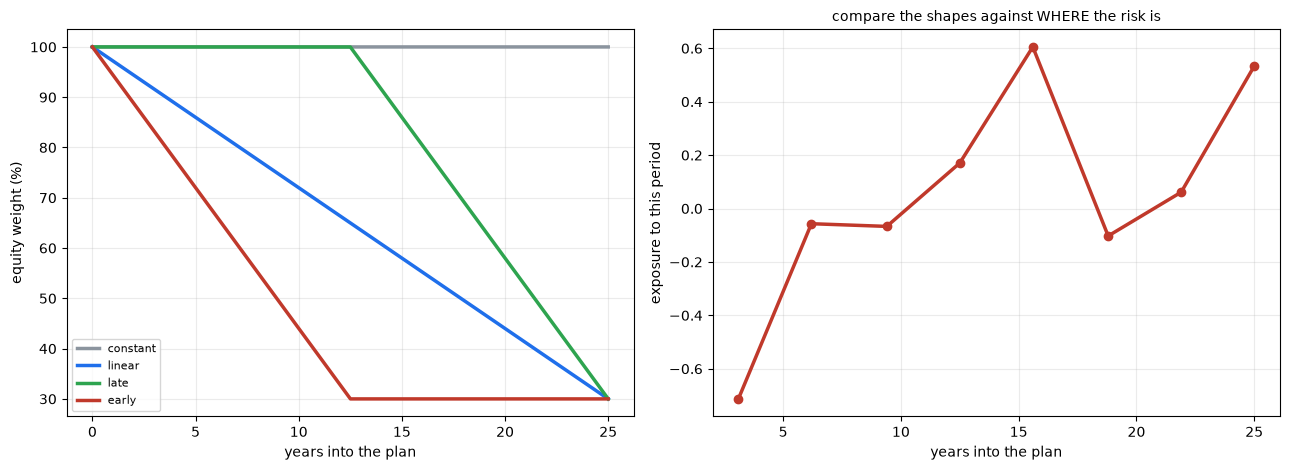

The 'late' shape holds equity while exposure is low and de-risks where it
is high. The 'early' shape does the reverse, which is why it scores worst.


In [9]:
h = 25 * 252
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for shape, col in (("constant", "#8b949e"), ("linear", "#1f6feb"),
                   ("late", "#2ea44f"), ("early", "#c0392b")):
    w = st.glide_path(h, 1.0, 0.3, shape)
    axes[0].plot(np.linspace(0, 25, h), w * 100, lw=2.5, color=col, label=shape)
axes[0].set_xlabel("years into the plan"); axes[0].set_ylabel("equity weight (%)")
axes[0].legend(fontsize=8)
m = st.sequence_risk_metrics(r, 25, n_buckets=8)
axes[1].plot(m["years_to"], m["corr_contributor"], "o-", lw=2.5, color="#c0392b")
axes[1].set_xlabel("years into the plan")
axes[1].set_ylabel("exposure to this period")
axes[1].set_title("compare the shapes against WHERE the risk is", fontsize=10)
plt.tight_layout(); plt.show()
print("The 'late' shape holds equity while exposure is low and de-risks where it")
print("is high. The 'early' shape does the reverse, which is why it scores worst.")

### 3.7 The decumulation mirror

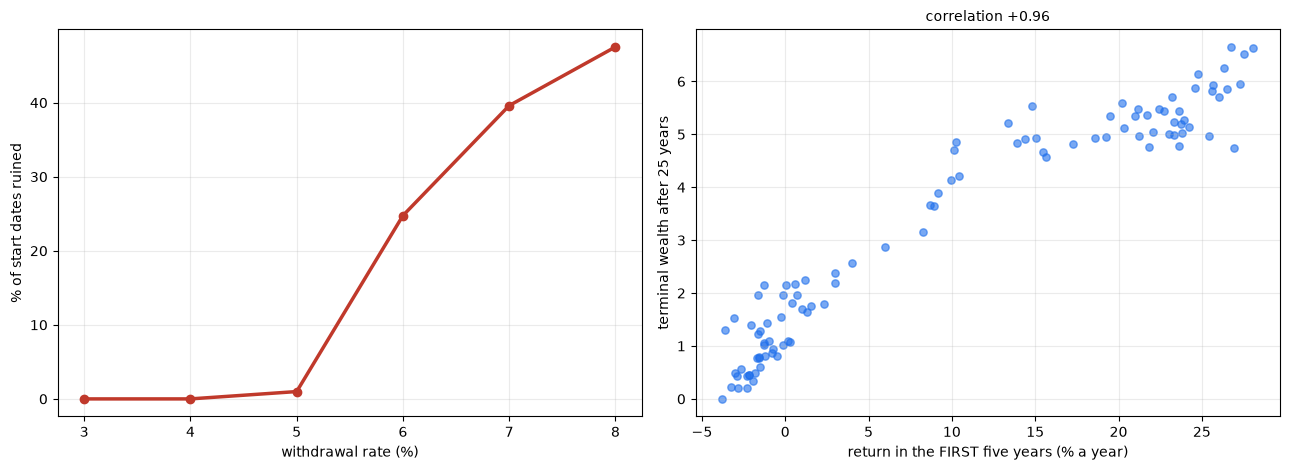

         ruin  median    p05  corr_first5
rate                                     
0.0300 0.0000  5.5490 2.7960       0.9450
0.0400 0.0000  4.6040 1.6320       0.9560
0.0500 0.0100  3.6430 0.4400       0.9610
0.0600 0.2480  2.6100 0.0000       0.9700
0.0700 0.3960  1.5770 0.0000       0.9810
0.0800 0.4750  0.5450 0.0000       0.9750


In [10]:
rows = []
for w in (0.03, 0.04, 0.05, 0.06, 0.07, 0.08):
    dd = st.decumulation_paths(r, 25, w)
    rows.append({"rate": w, "ruin": dd["ruined"].mean(),
                 "median": dd["terminal"].median(),
                 "p05": dd["terminal"].quantile(0.05),
                 "corr_first5": dd["first_5y_cagr"].corr(dd["terminal"])})
d = pd.DataFrame(rows).set_index("rate")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index * 100, d["ruin"] * 100, "o-", lw=2.5, color="#c0392b")
axes[0].set_xlabel("withdrawal rate (%)"); axes[0].set_ylabel("% of start dates ruined")
dd = st.decumulation_paths(r, 25, 0.05)
axes[1].scatter(dd["first_5y_cagr"] * 100, dd["terminal"], s=28, alpha=0.6,
                color="#1f6feb")
axes[1].set_xlabel("return in the FIRST five years (% a year)")
axes[1].set_ylabel("terminal wealth after 25 years")
axes[1].set_title(f"correlation {dd['first_5y_cagr'].corr(dd['terminal']):+.2f}",
                  fontsize=10)
plt.tight_layout(); plt.show()
print(d.round(3).to_string())

> \U0001F4A1 **In plain words.** For a saver the last years decide the outcome; for a retiree the
> first five do. Any glide path that de-risks smoothly across a lifetime is aimed at neither
> concentration.

## 4 · The verdict

In [11]:
acc = st.accumulation_paths(r, 25)
d = st.path_dispersion(acc, "multiple")
dl = st.path_dispersion(acc, "lump_sum")
sh = st.shuffle_invariance(r.to_numpy()[-int(25*252):], 1/21, n_shuffles=400)
m = st.sequence_risk_metrics(r, 25, n_buckets=6)
rem = st.remedy_comparison(e, b, REMEDY_YEARS)
if rem.empty:
    rem = st.remedy_comparison(e, b, 15)
scored = rem.drop(index="100% equity throughout", errors="ignore")
scored = scored[np.isfinite(scored["efficiency"])]
best = scored["efficiency"].idxmax()
pd.DataFrame({
    "start dates tested": [d["n_paths"]],
    "effective independent observations": [d["effective_n"]],
    "best outcome": [d["max"]],
    "worst outcome": [d["min"]],
    "best / worst": [d["ratio_max_min"]],
    "95th / 5th, contributor": [d["ratio_95_05"]],
    "95th / 5th, lump sum": [dl["ratio_95_05"]],
    "pure sequence risk (shuffled)": [sh["sequence_spread"]],
    "exposure, first sixth": [m["corr_contributor"].iloc[0]],
    "exposure, final sixth": [m["corr_contributor"].iloc[-1]],
    "most efficient remedy": [best],
    "its dispersion reduction": [scored.loc[best, "cv_reduction"]],
    "its median cost": [scored.loc[best, "median_cost"]],
    "its efficiency": [scored.loc[best, "efficiency"]],
}).T.rename(columns={0: "value"})

,value
start dates tested,101
effective independent observations,1.3341
best outcome,5.9104
worst outcome,2.8471
best / worst,2.0760
"95th / 5th, contributor",1.6917
"95th / 5th, lump sum",1.7528
pure sequence risk (shuffled),2.5006
"exposure, first sixth",-0.6692
"exposure, final sixth",0.4256


## 5 · Going further

- **Estrada (2014)** finds conventional declining glide paths dominated across nineteen
  countries once both columns are scored. §3.5 reproduces that logic on one market; running it
  on a multi-country panel is the obvious extension and the one with real evidential weight.
- **Kitces & Pfau (2015)** argue for a *rising* equity glide in retirement, which §3.7's
  first-five-years concentration supports directly. Implementing a rising path in
  `glide_path` and scoring it on the decumulation paths would close that loop.
- **Human capital is the missing asset.** Bodie, Merton & Samuelson (1992): a young saver's
  bond-like future earnings are the real reason to hold equity early, not the horizon. Adding a
  labour-income stream would change §3.5's ranking and is the most important omission here.
- **Valuation-conditioned start dates.** The worst start dates in §1 cluster at high valuations.
  Conditioning the analysis on CAPE would turn a lottery into a partially forecastable one,
  which is either the most useful extension or the most dangerous, depending on how much you
  trust the conditioning.